# P2 · 카테고리 정제 + 개인 소비 변화 분석

**담당**: P2 · **기능**: 개인 소비 변화 분석 및 예측 (중 '변화 분석' 파트)

| 산출물 | 역할 |
|---|---|
| `src/classify.py` | 카테고리 64종 → 20종 정규화, 20종 → 대분류 12개, 가맹점 사전, 결측 가맹점 보완 |
| `src/change.py` | 고객·월·대분류 지출, 전월·직전 3개월 대비 증감, 급증/급감/신규 판정, `analyze()` |
| `sql/queries_P2.sql` | 같은 계산의 SQL 버전 (교차검증용) |
| 이 노트북 | 진단 → 정제 → SQL 실행 → **SQL·Pandas 교차검증** → 변화 분석 결과 |

순서
1. 데이터 불러오기
2. 원본 카테고리 진단
3. 정규화·대분류·가맹점 사전
4. SQL 실행
5. SQL ↔ Pandas 교차검증
6. 전체 고객 월별 지출 추이
7. 급증 판정 기준 점검 (민감도)
8. 고객 1명 예시 (`analyze()` 출력)
9. 정리 · ai_log 후보

In [1]:
import sys, platform, sqlite3, re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT / "src"))
DATA = ROOT / "data" / "transactions.csv"
OUT_PD = ROOT / "results" / "pandas"; OUT_PD.mkdir(parents=True, exist_ok=True)
OUT_SQL = ROOT / "results" / "sql"; OUT_SQL.mkdir(parents=True, exist_ok=True)
OUT_FIG = ROOT / "results" / "figures"; OUT_FIG.mkdir(parents=True, exist_ok=True)

import warnings
from matplotlib import font_manager as fm
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# 한글 폰트: 설치된 것 중 첫 번째를 사용 (Windows / Mac / Linux·Colab)
for f in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
          "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if Path(f).exists():
        fm.fontManager.addfont(f)
_installed = {f.name for f in fm.fontManager.ttflist}
_font = next((n for n in ["Malgun Gothic", "AppleGothic", "NanumGothic",
                          "Noto Sans CJK KR", "Noto Sans CJK JP"] if n in _installed), None)
if _font:
    plt.rcParams["font.family"] = _font
else:
    print("한글 폰트를 찾지 못했습니다. Colab이면 !apt -qq install fonts-nanum 후 런타임 재시작")
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from classify import (add_categories, normalize_category, build_merchant_map,
                      classify_merchant, category_report, BIG_CATEGORY_ORDER)
from change import (monthly_spend, add_change_columns, change_table, analyze,
                    PCT_THRESHOLD, WON_THRESHOLD)
print("ROOT =", ROOT, "| font =", _font)

ROOT = /home/claude/repo | font = Noto Sans CJK JP


## 1. 데이터 불러오기

중복·취소 제거는 P1의 `loader.load_clean()` 담당입니다. loader가 아직 머지되지 않았으면 같은 규칙의 **임시 정제**를 씁니다.
- 중복: `transaction_id`만 다르고 나머지가 같은 행 제거
- 취소: `transaction_status == 'CANCELLED'` 제외

In [2]:
try:
    from loader import load_clean
    tx = load_clean()
    print("P1 loader 사용")
except ImportError:
    raw = pd.read_csv(DATA)
    n0 = len(raw)
    tx = raw.drop_duplicates(subset=[c for c in raw.columns if c != "transaction_id"])
    n_dup = n0 - len(tx)
    tx = tx[tx["transaction_status"] == "APPROVED"].copy()
    n_cancel = n0 - n_dup - len(tx)
    print(f"임시 정제: 원본 {n0:,}행 → 중복 {n_dup:,} 제거 → 취소 {n_cancel:,} 제외 → {len(tx):,}행")

tx["ym"] = pd.to_datetime(tx["transaction_datetime"]).dt.strftime("%Y-%m")
tx.head(3)

임시 정제: 원본 318,145행 → 중복 943 제거 → 취소 6,403 제외 → 310,799행


,transaction_id,customer_id,persona_id,age_group,gender,occupation,annual_income,household_type,transaction_datetime,merchant_name,category,amount,payment_method,card_product,transaction_status,ym
0,TX000001,C0487,P04,30s,F,OFFICE_WORKER,34600000,SINGLE,2025-01-01 00:00:37,쿠팡와우,SUBSCRIPTION,7890,CHECK_CARD,CARD_A,APPROVED,2025-01
1,TX000002,C0550,P16,30s,F,OFFICE_WORKER,77680000,NEWLYWED,2025-01-01 00:03:22,티빙,SUBSCRIPTION,13900,CHECK_CARD,CARD_C,APPROVED,2025-01
2,TX000003,C0735,P08,30s,M,OFFICE_WORKER,55440000,NEWLYWED,2025-01-01 00:14:24,어도비 Creative Cloud,SUBSCRIPTION,30800,CHECK_CARD,CARD_A,APPROVED,2025-01


## 2. 원본 카테고리 진단

대소문자·공백·오타 때문에 실제 20종이 여러 표기로 흩어져 있습니다.

In [3]:
raw_cats = tx["category"].value_counts()
print("원본 category 고유값:", tx["category"].nunique())
print("strip().upper() 후:", tx["category"].str.strip().str.upper().nunique())
print("정규화 후:", normalize_category(tx["category"]).nunique())

rep = category_report(tx)
rep.to_csv(OUT_PD / "p2_category_mapping.csv", index=False, encoding="utf-8-sig")
# 표기 변형이 있는 카테고리만 보기
multi = rep.groupby("category_std")["category_raw"].transform("count") > 1
rep[multi].head(20)

원본 category 고유값: 64
strip().upper() 후: 24


정규화 후: 20


,category_std,category_raw,rows
0,ACCOMMODATION,ACCOMMODATION,2534
2,ACCOMMODATION,accommodation,9
1,ACCOMMODATION,ACCOMMODATION,1
3,BUSINESS,BUSINESS,2501
5,BUSINESS,business,5
4,BUSINESS,BUSINESS,1
6,CAFE,CAFE,26987
9,CAFE,cafe,19
7,CAFE,CAFE,16
8,CAFE,CAFFE,10


## 3. 정규화 · 대분류 · 가맹점 사전

In [4]:
df = add_categories(tx)

# 검증 1: 표준 카테고리 20종, 대분류 누락 없음
assert df["category_std"].nunique() == 20
assert df["big_category"].isna().sum() == 0
# 검증 2: 정규화는 행을 바꾸지 않는다 → 금액 합계 동일
assert df["amount"].sum() == tx["amount"].sum()
print("정규화 검증 통과 · 총 금액", f"{df['amount'].sum():,}원")

big = (df.groupby("big_category")
         .agg(rows=("amount", "size"), amount=("amount", "sum"),
              categories=("category_std", lambda s: ", ".join(sorted(s.unique()))))
         .reindex(BIG_CATEGORY_ORDER))
big["share_%"] = (big["amount"] / big["amount"].sum() * 100).round(1)
big

정규화 검증 통과 · 총 금액 19,571,938,740원


,rows,amount,categories,share_%
big_category,,,,
식비,87099,4056943560,"CONVENIENCE, DINING, GROCERY",20.7
카페,27032,141301450,CAFE,0.7
배달,21081,507373730,DELIVERY,2.6
교통,28495,814917180,"FUEL, TRANSPORT",4.2
쇼핑,49708,6084797400,"FASHION, HOUSEHOLD, ONLINE_SHOPPING",31.1
구독,19893,240942570,SUBSCRIPTION,1.2
주거통신,39223,2430944640,UTILITY,12.4
의료,8392,384091740,MEDICAL,2.0
교육,5582,771033020,EDUCATION,3.9


In [5]:
merchant_map = build_merchant_map(df)
print("가맹점 사전 크기:", len(merchant_map))

# 검증 3: 정규화 후 한 가맹점이 두 카테고리에 걸리는 충돌이 없는지
conflict = (df.dropna(subset=["merchant_name"])
              .groupby("merchant_name")["category_std"].nunique())
print("카테고리 충돌 가맹점 수:", int((conflict > 1).sum()))

# 가맹점명만으로 분류: 사전에 없는 표기(지점명 등)도 부분 일치로 처리
examples = ["스타벅스 강남점", "배달의민족", "코레일KTX 서울역", "코레일", "GS25 해운대점", "처음보는가게"]
pd.DataFrame({"merchant_name": examples,
              "분류 결과": [classify_merchant(m, merchant_map) for m in examples]})

가맹점 사전 크기: 147
카테고리 충돌 가맹점 수: 0


,merchant_name,분류 결과
0,스타벅스 강남점,CAFE
1,배달의민족,DELIVERY
2,코레일KTX 서울역,TRAVEL
3,코레일,TRANSPORT
4,GS25 해운대점,CONVENIENCE
5,처음보는가게,NaN


In [6]:
# 결측 가맹점 보완 결과
miss = df[df["merchant_name"].isna()]
print(f"merchant_name 결측 {len(miss):,}건 → '미상(대분류)'로 채움")
miss["merchant_filled"].value_counts().head(8)

merchant_name 결측 1,092건 → '미상(대분류)'로 채움


merchant_filled
미상(식비)      287
미상(쇼핑)      178
미상(주거통신)    128
미상(카페)      104
미상(교통)      102
미상(구독)       78
미상(배달)       68
미상(여가)       53
Name: count, dtype: int64

## 4. SQL 실행

정제된 거래를 SQLite에 올리고 `sql/queries_P2.sql`을 블록(`-- [이름]`) 단위로 실행합니다. 정규화는 SQL 쪽에서 **독립적으로** 다시 계산합니다(`tx_std` 뷰). 그래야 교차검증이 의미가 있습니다.

In [7]:
con = sqlite3.connect(ROOT / "results" / "p2.db")
cols = ["transaction_id", "customer_id", "transaction_datetime", "ym",
        "merchant_name", "category", "amount", "payment_method", "card_product"]
tx[cols].to_sql("transactions_clean", con, if_exists="replace", index=False)

sql_text = (ROOT / "sql" / "queries_P2.sql").read_text(encoding="utf-8")
blocks = {}
for part in re.split(r"^-- \[", sql_text, flags=re.M)[1:]:
    name, body = part.split("]", 1)
    blocks[name.strip()] = body

con.executescript(blocks.pop("SETUP"))

def run(name, **params):
    key = next(k for k in blocks if k.startswith(name))
    return pd.read_sql(blocks[key], con, params=params or None)

print("쿼리 블록:", list(blocks))

쿼리 블록: ['P2-01 원본 카테고리 표기 변형 목록', 'P2-02 정규화 결과 검증', 'P2-03 가맹점별 카테고리 일관성', 'P2-04 가맹점명 결측 현황', 'P2-05 대분류별 월 지출 (전체 고객)', 'P2-06 고객별 월 변화표 (전체)', 'P2-07 한 고객·한 달의 급증/급감 판정', 'P2-08 월별 급증 판정 비율']


In [8]:
q01 = run("P2-01"); q01.to_csv(OUT_SQL / "p2_01_category_variants.csv", index=False, encoding="utf-8-sig")
q02 = run("P2-02"); q02.to_csv(OUT_SQL / "p2_02_normalize_check.csv", index=False, encoding="utf-8-sig")
q03 = run("P2-03")
q04 = run("P2-04"); q04.to_csv(OUT_SQL / "p2_04_missing_merchant.csv", index=False, encoding="utf-8-sig")
display(q02)
print("P2-03 가맹점 충돌 행 수:", len(q03))
q04

,n_category_raw,n_category_std,unmapped,total_amount
0,64,20,0,19571938740


P2-03 가맹점 충돌 행 수: 0


,big_category,missing_merchant_rows,amount
0,식비,287,13579760
1,쇼핑,178,18322110
2,주거통신,128,8233500
3,카페,104,518860
4,교통,102,2365300
5,구독,78,928030
6,배달,68,1682960
7,여가,53,1312320
8,의료,29,1122030
9,기타,24,2898520


## 5. SQL ↔ Pandas 교차검증

같은 수치를 두 방식으로 계산해 일치하는지 확인합니다. 모두 PASS여야 PR을 올립니다.

In [9]:
checks = []
def check(name, ok, detail=""):
    checks.append({"검증": name, "결과": "PASS" if ok else "FAIL", "상세": detail})

# V1 정규화 결과
check("V1 표준 카테고리 20종 · 미매핑 0",
      int(q02.n_category_std[0]) == df["category_std"].nunique() == 20 and int(q02.unmapped[0]) == 0,
      f"SQL {int(q02.n_category_std[0])}종, Pandas {df['category_std'].nunique()}종")
check("V2 총 금액", int(q02.total_amount[0]) == int(df["amount"].sum()),
      f"{int(q02.total_amount[0]):,}원")

# V3 대분류 × 월 합계
q05 = run("P2-05"); q05.to_csv(OUT_SQL / "p2_05_monthly_big_category.csv", index=False, encoding="utf-8-sig")
pd05 = df.groupby(["ym", "big_category"], as_index=False)["amount"].sum()
m = q05.merge(pd05, on=["ym", "big_category"], suffixes=("_sql", "_pd"), how="outer", indicator=True)
check("V3 월 × 대분류 합계", (m["_merge"] == "both").all() and (m.amount_sql == m.amount_pd).all(),
      f"{len(m)}칸, 최대 차이 {int((m.amount_sql - m.amount_pd).abs().max())}")

# V4 고객별 변화표: 전월 금액·직전 3개월 평균
q06 = run("P2-06")
pd06 = add_change_columns(monthly_spend(df))
m = q06.merge(pd06, on=["customer_id", "ym", "big_category"], suffixes=("_sql", "_pd"))
d_amt = (m.amount_sql - m.amount_pd).abs().max()
d_prev = (m.prev_amount_sql - m.prev_amount_pd).abs().max()
d_avg = (m.avg_3m_sql - m.avg_3m_pd).abs().max()
check("V4 변화표 (금액·전월·3개월 평균)",
      len(m) == len(q06) == len(pd06) and max(d_amt, d_prev, d_avg) < 1e-6,
      f"{len(m):,}행, 최대 차이 금액 {d_amt} / 전월 {d_prev} / 평균 {d_avg:.6f}")

# V5 한 고객·한 달 판정 결과
CID, MONTH = "C0003", "2025-12"
q07 = run("P2-07", customer_id=CID, month=MONTH)
pd07 = change_table(df, CID, MONTH)[["big_category", "status"]].astype({"big_category": str})
m = q07[["big_category", "status"]].merge(pd07, on="big_category", suffixes=("_sql", "_pd"))
check(f"V5 {CID} {MONTH} 급증/급감 판정", (m.status_sql == m.status_pd).all(),
      f"{len(m)}개 대분류 중 일치 {(m.status_sql == m.status_pd).sum()}개")

val = pd.DataFrame(checks)
val.to_csv(OUT_PD / "p2_validation.csv", index=False, encoding="utf-8-sig")
val

,검증,결과,상세
0,V1 표준 카테고리 20종 · 미매핑 0,PASS,"SQL 20종, Pandas 20종"
1,V2 총 금액,PASS,"19,571,938,740원"
2,V3 월 × 대분류 합계,PASS,"144칸, 최대 차이 0"
3,V4 변화표 (금액·전월·3개월 평균),PASS,"144,000행, 최대 차이 금액 0 / 전월 0.0 / 평균 0.000000"
4,V5 C0003 2025-12 급증/급감 판정,PASS,12개 대분류 중 일치 12개


## 6. 전체 고객 월별 지출 추이

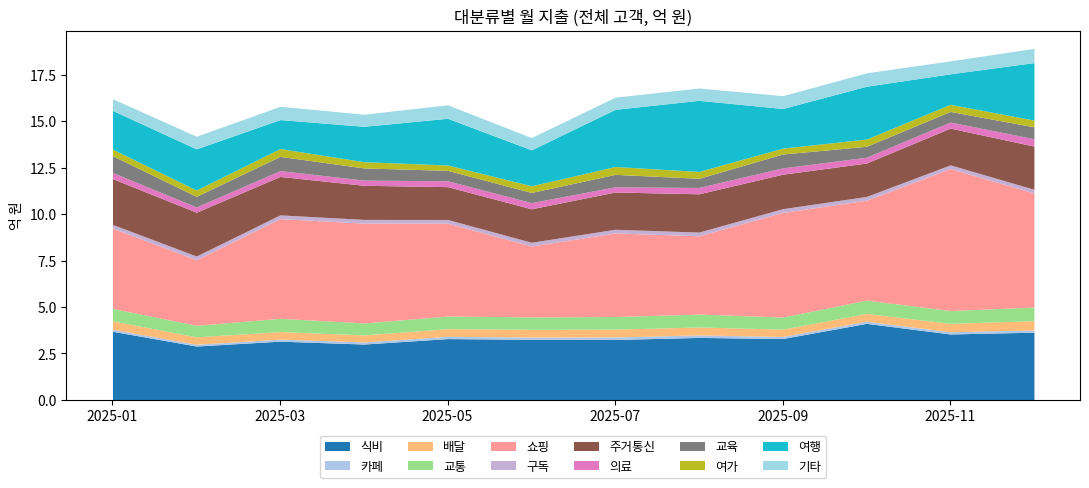

월 총지출(억 원): {'2025-01': 16.2, '2025-02': 14.2, '2025-03': 15.8, '2025-04': 15.4, '2025-05': 15.9, '2025-06': 14.1, '2025-07': 16.3, '2025-08': 16.8, '2025-09': 16.4, '2025-10': 17.6, '2025-11': 18.2, '2025-12': 18.9}


In [10]:
pivot = (df.groupby(["ym", "big_category"])["amount"].sum()
           .unstack()[BIG_CATEGORY_ORDER] / 1e8)
ax = pivot.plot(kind="area", stacked=True, figsize=(11, 5), colormap="tab20", linewidth=0)
ax.set_title("대분류별 월 지출 (전체 고객, 억 원)")
ax.set_xlabel(""); ax.set_ylabel("억 원")
ax.legend(ncol=6, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.08))
plt.tight_layout(); plt.savefig(OUT_FIG / "p2_monthly_big_category.png", dpi=150); plt.show()

mom = pivot.sum(axis=1)
print("월 총지출(억 원):", mom.round(1).to_dict())

## 7. 급증 판정 기준 점검 (민감도)

기준: **직전 3개월 평균 대비 ±30% 이상 AND ±3만 원 이상**. 비율만 쓰면 소액 변화가, 금액만 쓰면 원래 큰 카테고리의 자연스러운 흔들림이 잡힙니다. 기준이 너무 느슨하면 거의 모든 고객이 매달 '급증' 알림을 받게 되므로, 기준별로 12월에 급증 판정되는 비율을 확인합니다.

In [11]:
dec = pd06[(pd06["ym"] == "2025-12")]
print("현재 기준 12월 상태 분포")
display(dec["status"].value_counts().to_frame("칸 수").assign(비율=lambda x: (x["칸 수"] / len(dec) * 100).round(1)))

rows = []
for pct in [0.3, 0.5, 1.0]:
    for wn in [30_000, 50_000, 100_000]:
        spike = (dec["pct_3m"] >= pct) & (dec["diff_3m"] >= wn)
        cust = dec.loc[spike, "customer_id"].nunique()
        rows.append({"비율 기준": f"+{int(pct*100)}%", "금액 기준": f"+{wn//10000}만 원",
                     "급증 칸 비율(%)": round(spike.mean() * 100, 1),
                     "급증 알림 받는 고객 비율(%)": round(cust / dec["customer_id"].nunique() * 100, 1)})
sens = pd.DataFrame(rows)
sens.to_csv(OUT_PD / "p2_threshold_sensitivity.csv", index=False, encoding="utf-8-sig")
sens

현재 기준 12월 상태 분포


,칸 수,비율
status,,
유지,7201,60.0
급감,2397,20.0
급증,2087,17.4
신규,315,2.6


,비율 기준,금액 기준,급증 칸 비율(%),급증 알림 받는 고객 비율(%)
0,+30%,+3만 원,17.4,89.5
1,+30%,+5만 원,14.2,83.3
2,+30%,+10만 원,9.1,68.1
3,+50%,+3만 원,14.0,82.0
4,+50%,+5만 원,12.1,77.1
5,+50%,+10만 원,8.3,64.6
6,+100%,+3만 원,10.4,71.4
7,+100%,+5만 원,9.0,65.8
8,+100%,+10만 원,6.6,54.9


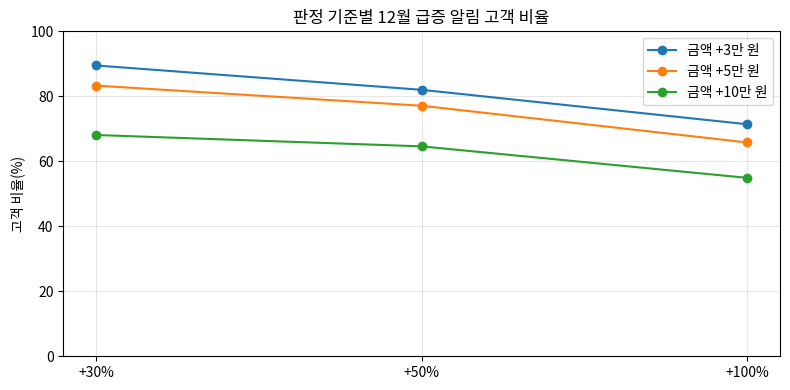

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for wn, grp in sens.groupby("금액 기준", sort=False):
    ax.plot(grp["비율 기준"], grp["급증 알림 받는 고객 비율(%)"], marker="o", label=f"금액 {wn}")
ax.set_title("판정 기준별 12월 급증 알림 고객 비율")
ax.set_ylabel("고객 비율(%)"); ax.set_ylim(0, 100); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT_FIG / "p2_threshold_sensitivity.png", dpi=150); plt.show()

# 12월 변화표 저장 (다른 파트가 참고)
dec.to_csv(OUT_PD / "p2_change_2025-12.csv", index=False, encoding="utf-8-sig")

## 8. 고객 1명 예시 — `analyze()` 출력

`report.py`가 호출하는 공통 인터페이스 결과입니다.

In [13]:
res = analyze(df, CID, MONTH)
print(res["title"], "|", res["message"])
print(res["data"]["headline"])
for msg in res["data"]["messages"]:
    print(" -", msg)

tbl = pd.DataFrame(res["data"]["table"])
tbl

소비 변화 | 이번 달 식비 지출이 최근 3개월 평균보다 286% 늘었어요 (+43만 원).
이번 달 총 80만 7천 원 썼어요. 최근 3개월 평균보다 6% 적어요.
 - 이번 달 식비 지출이 최근 3개월 평균보다 286% 늘었어요 (+43만 원).
 - 이번 달 쇼핑 지출이 최근 3개월 평균보다 100% 줄었어요 (-30만 원). 잘하고 있어요!
 - 이번 달 교육 지출이 최근 3개월 평균보다 83% 줄었어요 (-15만 9천 원). 잘하고 있어요!


,big_category,amount,prev_amount,avg_3m,diff_3m,pct_3m,status
0,식비,580220,313530.0,150156.666667,430063.333333,2.864097,급증
1,카페,18570,22090.0,20460.000000,-1890.000000,-0.092375,유지
2,배달,42200,19500.0,29770.000000,12430.000000,0.417534,유지
3,교통,48180,58550.0,69576.666667,-21396.666667,-0.307526,유지
4,쇼핑,0,65600.0,300600.000000,-300600.000000,-1.000000,급감
5,구독,48690,48690.0,48690.000000,0.000000,0.000000,유지
6,주거통신,29700,29700.0,29700.000000,0.000000,0.000000,유지
7,의료,0,0.0,993.333333,-993.333333,-1.000000,유지
8,교육,31820,542600.0,190866.666667,-159046.666667,-0.833287,급감
9,여가,7620,0.0,14796.666667,-7176.666667,-0.485019,유지


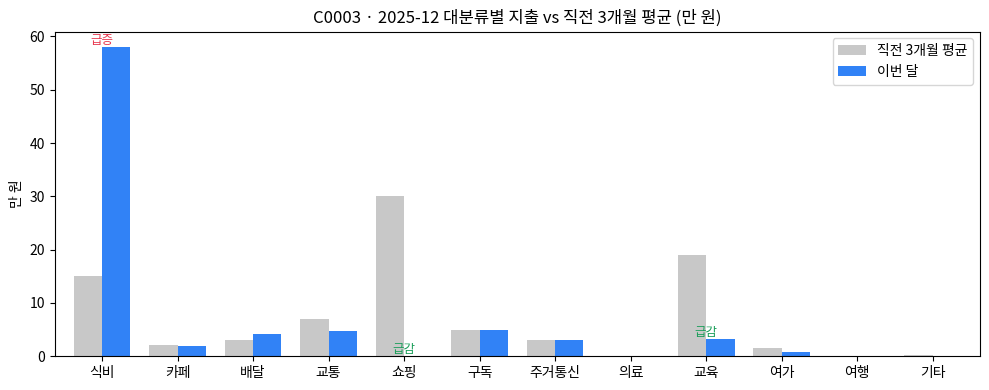

In [14]:
t = tbl.set_index("big_category")[["avg_3m", "amount"]] / 10_000
ax = t.plot(kind="bar", figsize=(10, 4), color=["#c8c8c8", "#3182f6"], width=0.75)
ax.set_title(f"{CID} · {MONTH} 대분류별 지출 vs 직전 3개월 평균 (만 원)")
ax.set_xlabel(""); ax.set_ylabel("만 원"); ax.legend(["직전 3개월 평균", "이번 달"])
for i, s in enumerate(tbl["status"]):
    if s in ("급증", "급감", "신규"):
        ax.annotate(s, (i, t["amount"].iloc[i]), ha="center", va="bottom", fontsize=9,
                    color="#e8384f" if s != "급감" else "#1b9e5a")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(OUT_FIG / f"p2_example_{CID}_{MONTH}.png", dpi=150); plt.show()

## 9. 정리 · ai_log 후보

**결과**
- 원본 category 64종 → 표준 20종 → 대분류 12개. 정규화 전후 금액 합계 동일, 가맹점-카테고리 충돌 0건.
- 가맹점 사전 147개로 카테고리 없이 가맹점명만으로 분류 가능 (지점명 포함 표기도 부분 일치 처리).
- SQL(`tx_std` 뷰, `LAG`, 윈도우 평균)과 Pandas(`shift`, `rolling`) 결과가 5개 검증 항목 모두 일치.

**한계와 판단 (발표·ai_log에 쓸 것)**
- 섹션 7에서 보듯 현재 기준(±30%, ±3만 원)으로는 12월에 대부분 고객이 급증 알림을 받습니다. 가상데이터의 월별 흔들림이 크기 때문입니다. 알림 피로를 줄이려면 기준을 올리거나(예: +50%·+5만 원), 고객당 가장 큰 변화 1개만 보여주는 방식이 필요합니다. 기준 확정은 팀 논의 후 `change.py` 상수만 바꾸면 됩니다.
- 2025년 1월은 비교할 과거가 없어 '기준없음'으로 처리했습니다.
- 증감의 **원인**(이사, 여행 등)은 데이터로 확인할 수 없으므로 문구에 넣지 않습니다.